                    ds     y
0  2020-01-01 00:00:00  15.0
1  2020-01-01 01:00:00  15.0
2  2020-01-01 02:00:00  15.0
3  2020-01-01 03:00:00  15.0
4  2020-01-01 04:00:00  16.0


DEBUG:cmdstanpy:input tempfile: /tmp/tmpldtuv8t6/6ccmf9ac.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpldtuv8t6/j3ny6p1v.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=82592', 'data', 'file=/tmp/tmpldtuv8t6/6ccmf9ac.json', 'init=/tmp/tmpldtuv8t6/j3ny6p1v.json', 'output', 'file=/tmp/tmpldtuv8t6/prophet_modelmcbtww7f/prophet_model-20251001113922.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
11:39:23 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
11:40:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


                       ds         yhat   yhat_lower   yhat_upper
43867 2025-01-01 19:00:00  2892.845005    77.987097  5739.389618
43868 2025-01-01 20:00:00  1203.282726 -1800.387654  4156.388687
43869 2025-01-01 21:00:00   323.870857 -2690.751422  3304.140849
43870 2025-01-01 22:00:00    79.111412 -2734.602621  2816.261017
43871 2025-01-01 23:00:00    42.871215 -2759.978906  3170.870055


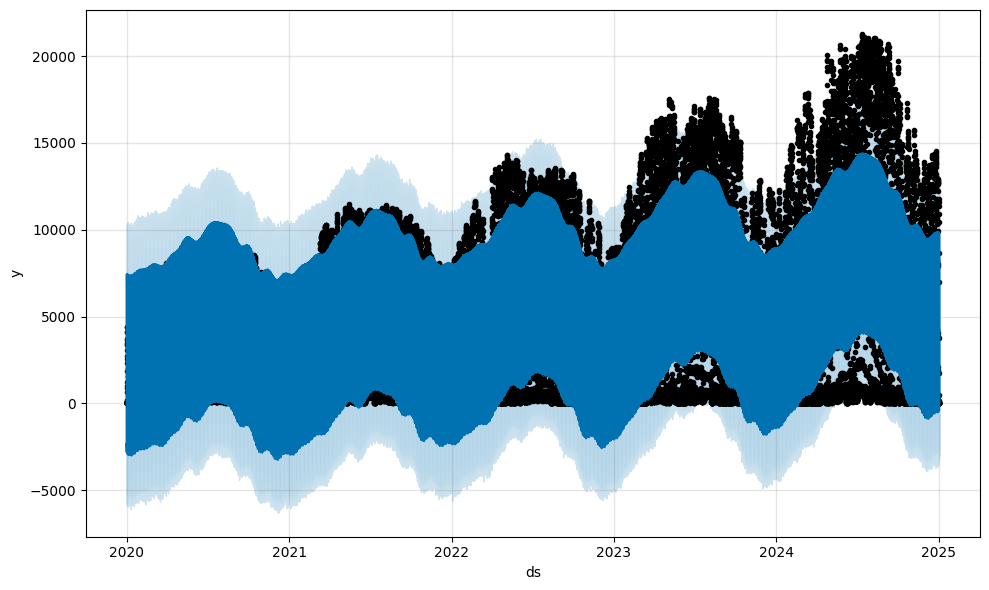

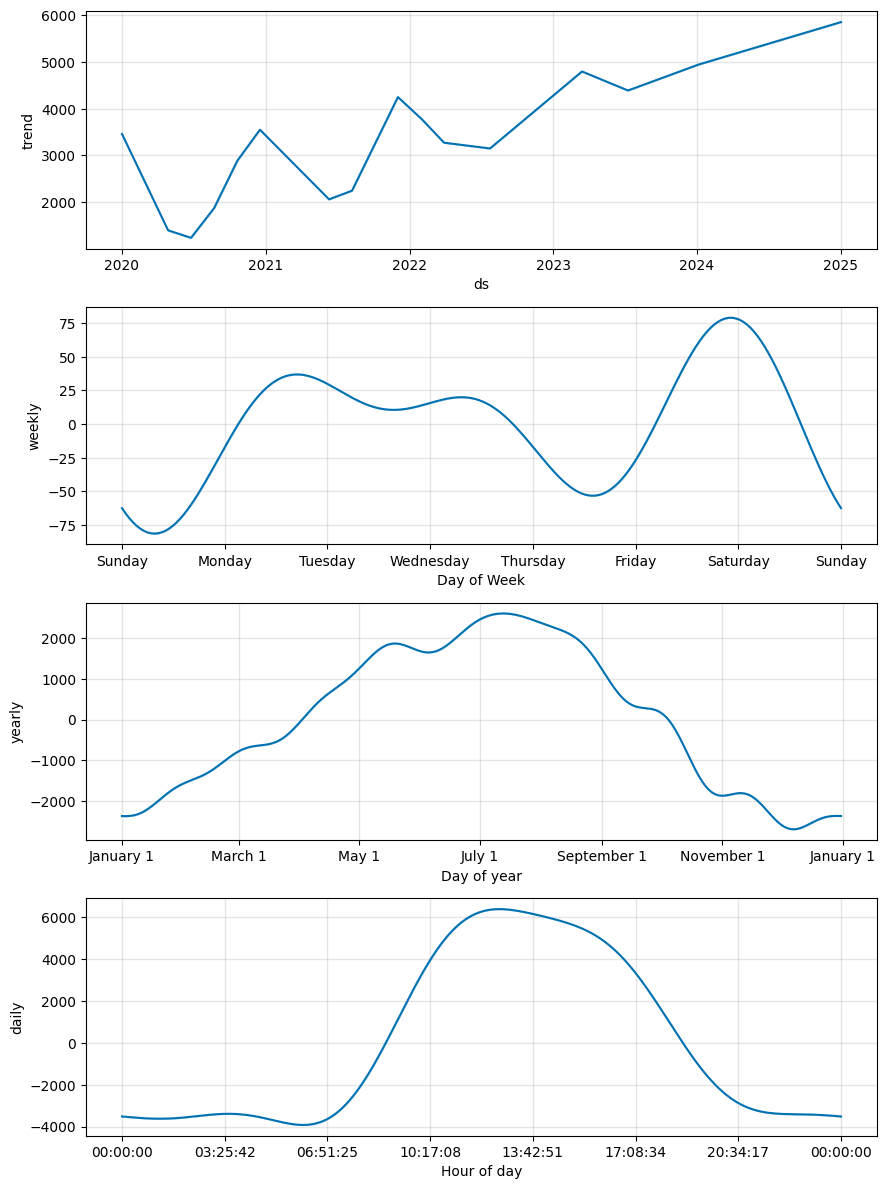

In [ ]:
import pandas as pd

# Load the dataset (assuming it's already uploaded to Colab)
df = pd.read_csv('/content/spain_renewables_master_2020_2024.csv')

# Prepare data for Prophet (solar_mw as target)
prophet_df = df[['timestamp', 'solar_mw']].rename(columns={'timestamp': 'ds', 'solar_mw': 'y'})

# Check the first few rows to confirm
print(prophet_df.head())

# Initialize and fit the Prophet model
from prophet import Prophet
m = Prophet()
m.fit(prophet_df)

# Create future dates for forecasting (e.g., next 24 hours)
future = m.make_future_dataframe(periods=24, freq='h')

# Make predictions
forecast = m.predict(future)

# View the forecast
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
# Plot the forecast
fig = m.plot(forecast)
# Plot forecast components (trend, seasonality)
fig2 = m.plot_components(forecast)
# Save the forecast plot
fig.savefig('/content/forecast_plot.png')
# Save the components plot
fig2.savefig('/content/components_plot.png')